In [ ]:
# ===============================
# Step 1: Import Required Libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [ ]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

In [ ]:
def evaluate_model(y_test, predictions):

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return rmse, r2


lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred)
ridge_rmse, ridge_r2 = evaluate_model(y_test, ridge_pred)
dt_rmse, dt_r2 = evaluate_model(y_test, dt_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2:", ridge_r2)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2:", dt_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2: 0.575787706032451
Ridge Regression RMSE: 0.7455567442814779
Ridge Regression R2: 0.5758157428913684
Decision Tree RMSE: 0.7028289572288925
Decision Tree R2: 0.6230424613065773


In [ ]:
results = pd.DataFrame({

    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],

    "RMSE": [lr_rmse, ridge_rmse, dt_rmse],

    "R2 Score": [lr_r2, ridge_r2, dt_r2]

})

print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745557  0.575816
2      Decision Tree  0.702829  0.623042


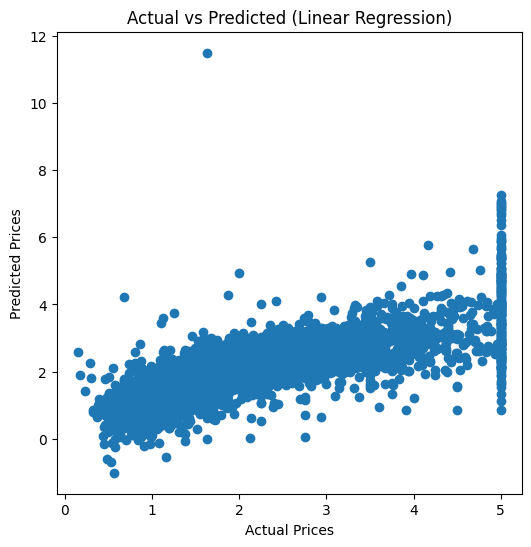

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted (Linear Regression)")

plt.show()